In [21]:
from attack_base import *
import torch

# 3D2Fool

## Setup Variables

In [ ]:
class Args(object):
    def __init__(self):
        self.camou_mask = './car/mask.jpg' # Location of mask
        self.camou_shape = 1024 #, help="shape of camouflage texture" #)
        self.obj_name = './car/lexus_hs.obj' #)
        device = 'cuda' #)
        self.device = torch.device(device)
        self.train_dir = '/data/zjh/mde_carla/' #)
        self.img_size = (320, 1024) #)
        self.batch_size = 16 #)
        self.lr = 0.01 #)
        self.log_dir = './res/' #)
        self.epochs = 5
        self.dev_count = 8

args = Args()
args.train_dir = './'

## Print Data 

dataset length:  8400


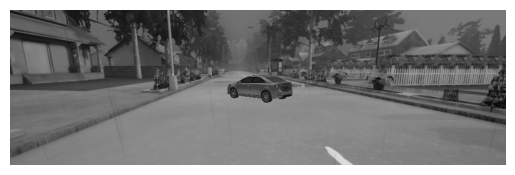

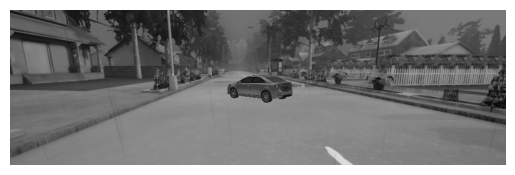

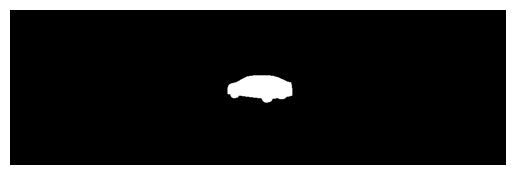

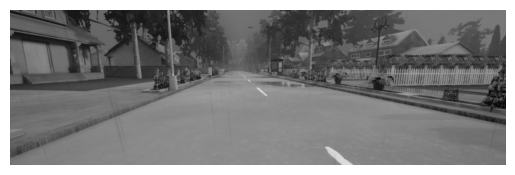

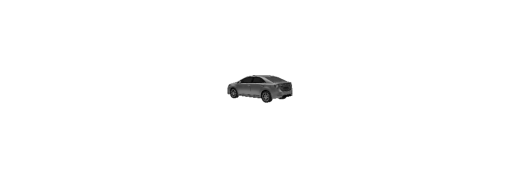

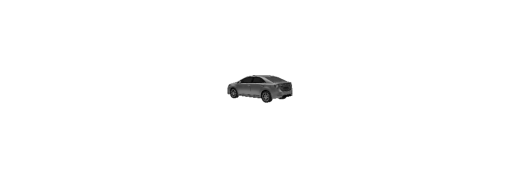

torch.Size([3, 320, 1024])
torch.Size([3, 320, 1024])


In [14]:
import matplotlib.pyplot as plt
from data_loader_mde import MyDataset
dataset = MyDataset(args.train_dir, args.img_size, args.obj_name, args.camou_mask, args.device)

index, total_img, total_img0, mask, img, pred1, pred0 = dataset[0]

plt.figure()
png0 = cv2.cvtColor((total_img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png0)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((total_img0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()



plt.figure()
png1 = cv2.cvtColor((mask[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()


plt.figure()
png1 = cv2.cvtColor((img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((pred0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((pred1[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

print(pred1.shape)
print(pred0.shape)

Use the expand kernel to create a kernel

In [18]:
H, W = args.camou_shape, args.camou_shape
resolution = 8
h, w = int(H/resolution), int(W/resolution)

expand_kernel = torch.nn.ConvTranspose2d(3, 3, resolution, stride=resolution, padding=0).to(args.device)
expand_kernel.weight.data.fill_(0)
expand_kernel.bias.data.fill_(0)
for i in range(3):
    expand_kernel.weight[i, i, :, :].data.fill_(1)

### Print Data with Camou Random

dataset length:  8400


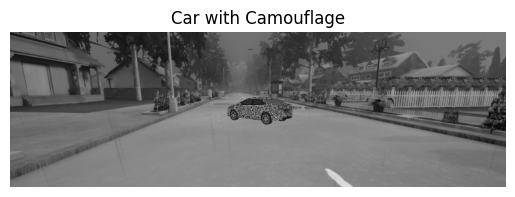

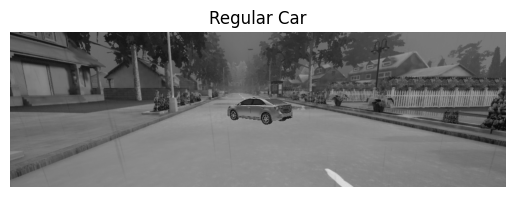

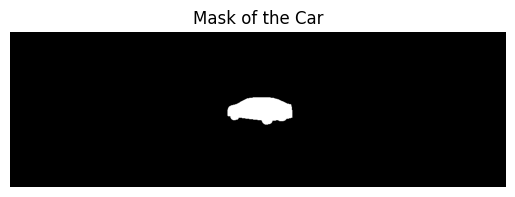

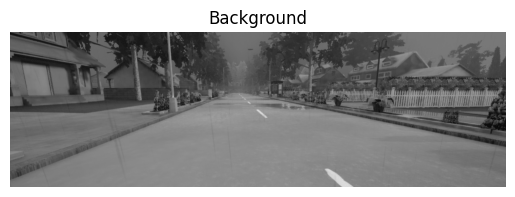

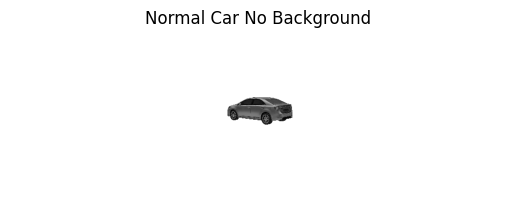

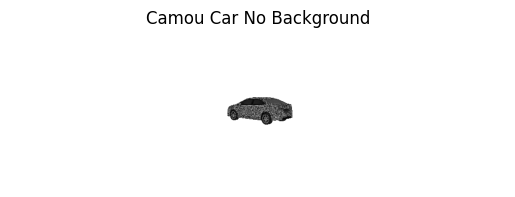

torch.Size([3, 320, 1024])
torch.Size([3, 320, 1024])


In [20]:
import matplotlib.pyplot as plt
from data_loader_mde import MyDataset
dataset = MyDataset(args.train_dir, args.img_size, args.obj_name, args.camou_mask, args.device)
camou_para = torch.rand([1, h, w, 3]).float().to(args.device)
camou_para1 = expand_kernel(camou_para.permute(0, 3, 1, 2)).permute(0, 2, 3, 1)
dataset.set_textures(camou_para1)

index, total_img, total_img0, mask, img, pred1, pred0 = dataset[0]

plt.figure()
plt.title('Car with Camouflage')
png0 = cv2.cvtColor((total_img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png0)
plt.axis('off')
plt.show()

plt.figure()
plt.title('Regular Car')
png1 = cv2.cvtColor((total_img0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()



plt.figure()
plt.title('Mask of the Car')
png1 = cv2.cvtColor((mask[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()


plt.figure()
plt.title('Background')
png1 = cv2.cvtColor((img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
plt.title('Normal Car No Background')
png1 = cv2.cvtColor((pred0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
plt.title('Camou Car No Background')
png1 = cv2.cvtColor((pred1[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

print(pred1.shape)
print(pred0.shape)

## Run the Attack Model

In [ ]:
depth_model, learned_expand_kernel, optimizer, begin_para, camou_para, camou_png = attack(args)
# torch.cuda.device_count()

/home/tkg5kq/.conda/envs/cars/lib/python3.8/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/tkg5kq/.conda/envs/cars/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


dataset length:  8400
------------------------------epoch begin: 0------------------------------


  0%|          | 0/525 [00:00<?, ?it/s]/home/tkg5kq/.conda/envs/cars/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1666642991888/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 525/525 [1:33:51<00:00, 10.73s/it]


------------------------------epoch begin: 1------------------------------


100%|██████████| 525/525 [1:33:49<00:00, 10.72s/it]


...

100%|██████████| 525/525 [1:33:53<00:00, 10.73s/it]


------------------------------epoch begin: 3------------------------------


100%|██████████| 525/525 [1:33:57<00:00, 10.74s/it]


------------------------------epoch begin: 4------------------------------


100%|██████████| 525/525 [1:33:53<00:00, 10.73s/it]


### Print Our Camou

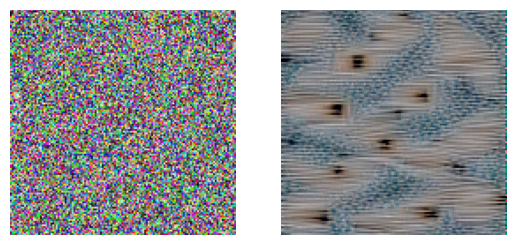

In [132]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(1, 2, 1)
begin_png = cv2.cvtColor((begin_para[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(begin_png)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(camou_png)
plt.axis('off')
plt.show()

In [29]:
depth_model.module

DepthModelWrapper(
  (encoder): ResnetEncoder(
    (encoder): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          

### Print Car with Trained Camou

dataset length:  8400


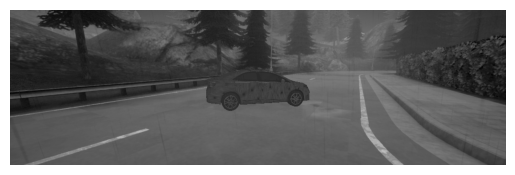

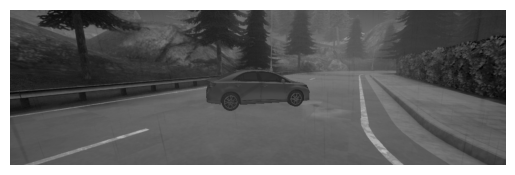

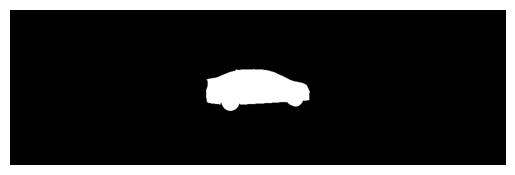

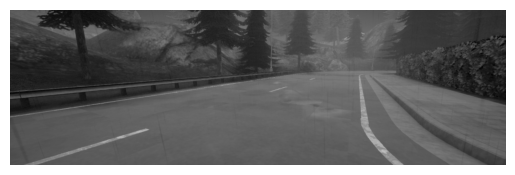

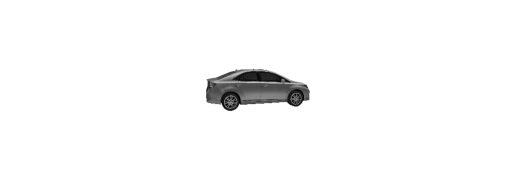

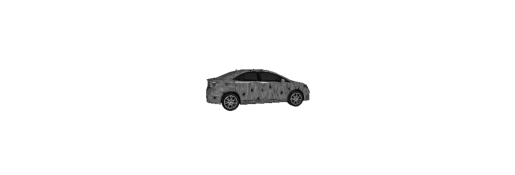

In [ ]:
camou_para1 = expand_kernel(camou_para.permute(0, 3, 1, 2)).permute(0, 2, 3, 1)
camou_para1 = torch.clamp(camou_para1, 0, 1)
dataset.set_textures(camou_para1)

idx = 2
index, total_img, total_img0, mask, img, pred1, pred0 = dataset[idx]

plt.figure()
png0 = cv2.cvtColor((total_img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png0)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((total_img0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()



plt.figure()
png1 = cv2.cvtColor((mask[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()


plt.figure()
png1 = cv2.cvtColor((img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((pred0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((pred1[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

### Run the Depth Model on the Dataset with Camou After 5 Epochs

In [52]:
model_name = "mono+stereo_1024x320"
encoder_path = os.path.join("models", model_name, "encoder.pth")
loaded_dict_enc = torch.load(encoder_path, map_location='cpu')
feed_height = loaded_dict_enc['height']
feed_width = loaded_dict_enc['width']
print(feed_height, feed_width)
input_resize = transforms.Resize([feed_height, feed_width])

320 1024


In [53]:
print(total_img.shape, total_img0.shape)
input_image = input_resize(total_img)
input_image0 = input_resize(total_img0)
print(input_image.shape, input_image0.shape)
with torch.no_grad():
    outputs = depth_model(input_image.unsqueeze(dim=0))
    outputs0 = depth_model(input_image0.unsqueeze(dim=0))

print(outputs.shape, outputs0.shape)

torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([1, 1, 320, 1024]) torch.Size([1, 1, 320, 1024])


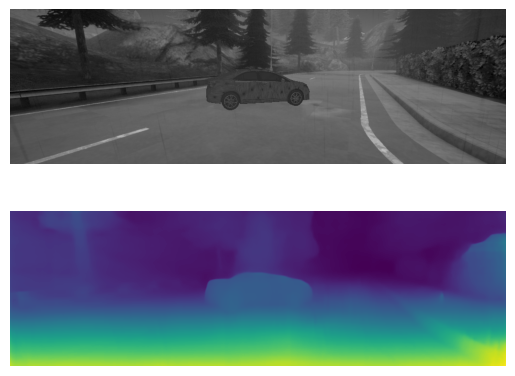

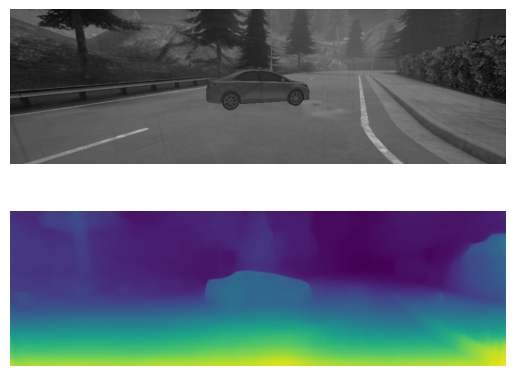

In [54]:
png0 = cv2.cvtColor((total_img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
outputs_png = outputs[0][0].detach().cpu().numpy()

plt.figure()
plt.subplot(2, 1, 1)
plt.imshow(png0)
plt.axis('off')
plt.subplot(2, 1, 2)
plt.imshow(outputs_png)
plt.axis('off')
plt.show()

png1 = cv2.cvtColor((total_img0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
outputs0_png = outputs0[0][0].detach().cpu().numpy()

plt.figure()
plt.subplot(2, 1, 1)
plt.imshow(png1)
plt.axis('off')
plt.subplot(2, 1, 2)
plt.imshow(outputs0_png)
plt.axis('off')
plt.show()

You can see this does not change the results of the depth chart. Now we will use the texture seed given by the authors

## Authors Camou Texture

In [55]:
from PIL import Image
from torchvision import transforms

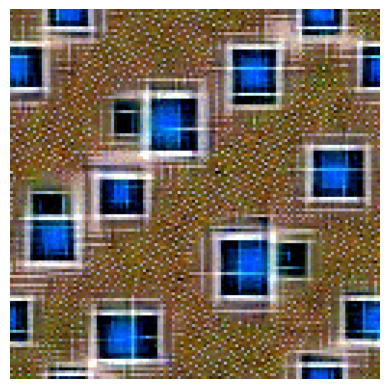

In [134]:
image_path = './texture_seed.png'

pil_image = Image.open(image_path)

to_tensor_transform = transforms.ToTensor()
image_tensor = to_tensor_transform(pil_image)
image_tensor.shape

plt.figure()
plt.imshow(image_tensor.permute(1, 2, 0))
plt.axis('off')
plt.show()

### Ours vs Theirs

torch.Size([1, 128, 128, 3])


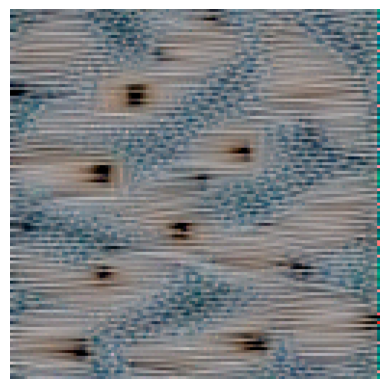

torch.Size([3, 1024, 1024])
torch.Size([1, 128, 128, 3])


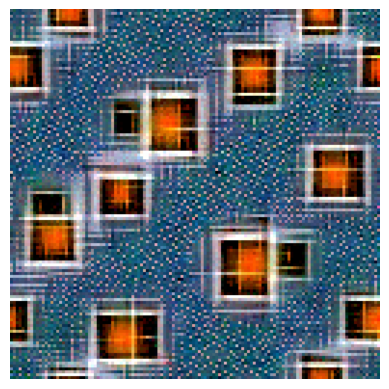

In [135]:
print(camou_para.shape)
plt.figure()
plt.imshow(camou_png)
plt.axis('off')
plt.show()

_, seed_height, seed_width, seed_channels = camou_para.shape


print(image_tensor.shape)
resize_seed = transforms.Resize([seed_height, seed_width])
seed_tensor = resize_seed(image_tensor).permute(1, 2, 0).unsqueeze(dim=0)
print(seed_tensor.shape)


model_device = next(depth_model.parameters()).device
seed_tensor_cuda = seed_tensor.to(device=model_device)
camou_para1 = expand_kernel(seed_tensor_cuda.permute(0, 3, 1, 2)).permute(0, 2, 3, 1)
camou_para1 = torch.clamp(camou_para1, 0, 1)

camou_png_clamped = cv2.cvtColor((camou_para1[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)

plt.figure()
plt.imshow(camou_png_clamped)
plt.axis('off')
plt.show()

### Apply the Camou to the Car Again

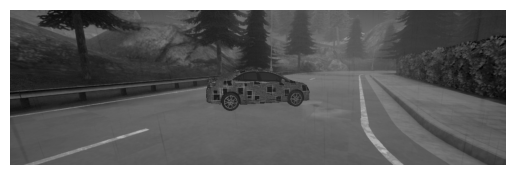

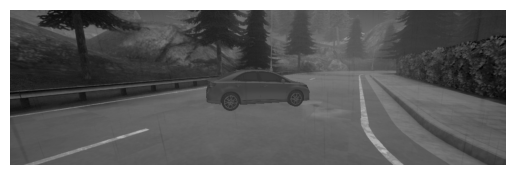

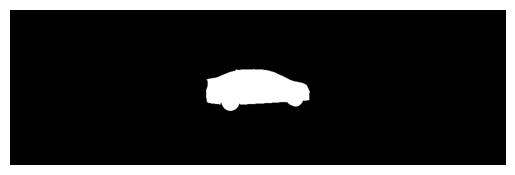

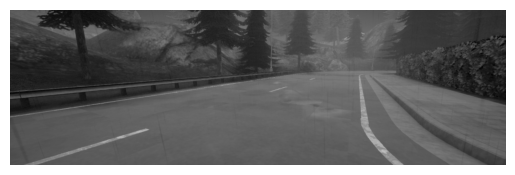

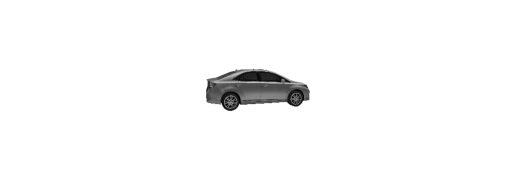

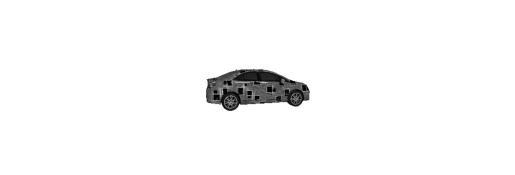

In [ ]:
dataset.set_textures(camou_para1)

idx = 2
index, total_img, total_img0, mask, img, pred1, pred0 = dataset[idx]

plt.figure()
png0 = cv2.cvtColor((total_img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png0)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((total_img0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()



plt.figure()
png1 = cv2.cvtColor((mask[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()


plt.figure()
png1 = cv2.cvtColor((img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((pred0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

plt.figure()
png1 = cv2.cvtColor((pred1[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
plt.imshow(png1)
plt.axis('off')
plt.show()

torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])


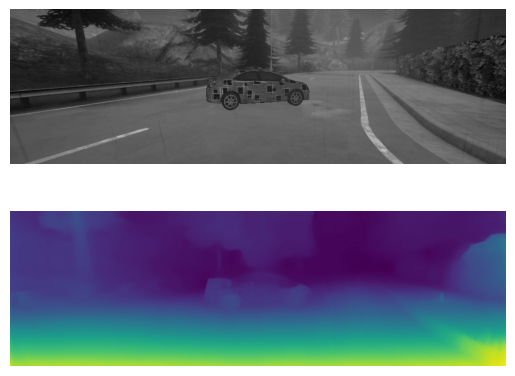

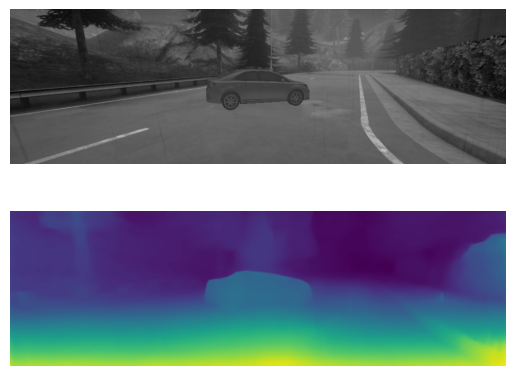

In [76]:
print(total_img.shape, total_img0.shape)
input_image = input_resize(total_img)
input_image0 = input_resize(total_img0)
print(input_image.shape, input_image0.shape)
with torch.no_grad():
    new_outputs = depth_model(input_image.unsqueeze(dim=0))
    new_outputs0 = depth_model(input_image0.unsqueeze(dim=0))

png0 = cv2.cvtColor((total_img[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
outputs_png = new_outputs[0][0].detach().cpu().numpy()

plt.figure()
plt.subplot(2, 1, 1)
plt.imshow(png0)
plt.axis('off')
plt.subplot(2, 1, 2)
plt.imshow(outputs_png)
plt.axis('off')
plt.show()

png1 = cv2.cvtColor((total_img0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
outputs0_png = new_outputs0[0][0].detach().cpu().numpy()

plt.figure()
plt.subplot(2, 1, 1)
plt.imshow(png1)
plt.axis('off')
plt.subplot(2, 1, 2)
plt.imshow(outputs0_png)
plt.axis('off')
plt.show()

The car now disappears when the camouflage is applied

# Fun Examples

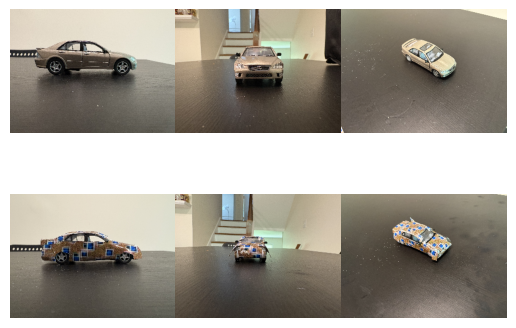

In [150]:
car_layout = './test/IMG_4041.jpg'
car_side = './test/IMG_4042.jpg'
car_front = './test/IMG_4043.jpg'
car_angle = './test/IMG_4045.jpg'
car_camou_side = './test/IMG_4046.jpg'
car_camou_front = './test/IMG_4047.jpg'
car_camou_angle = './test/IMG_4048.jpg'
image_paths = [car_side, car_front, car_angle, car_camou_side, car_camou_front, car_camou_angle]

def print_list(image_paths):
    car_tensors = []
    i = 1
    plt.figure()
    for image_path in image_paths:
        plt.subplot(2, 3, i)
        pil_image = Image.open(image_path).transpose(Image.FLIP_TOP_BOTTOM).transpose(Image.FLIP_LEFT_RIGHT)
        to_tensor_transform = transforms.ToTensor()
        image_tensor = to_tensor_transform(pil_image)

        # print(image_tensor.shape)
        resize_seed = transforms.Resize([240, 320])
        car_tensor = resize_seed(image_tensor).permute(1, 2, 0)
        car_tensors.append(image_tensor)
        # print(seed_tensor.shape)
        plt.imshow(car_tensor)
        plt.axis('off')
        i += 1

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    return car_tensors

car_tensors = print_list(image_paths)

torch.Size([3, 3024, 4032]) torch.Size([3, 3024, 4032])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([1, 1, 320, 1024]) torch.Size([1, 1, 320, 1024])


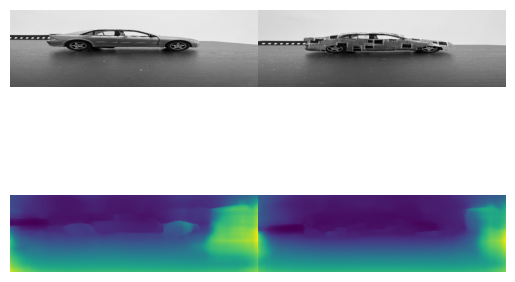

torch.Size([3, 3024, 4032]) torch.Size([3, 3024, 4032])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])


torch.Size([1, 1, 320, 1024]) torch.Size([1, 1, 320, 1024])


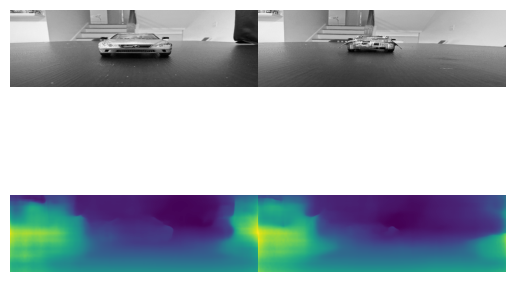

torch.Size([3, 4284, 5712]) torch.Size([3, 4284, 5712])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([1, 1, 320, 1024]) torch.Size([1, 1, 320, 1024])


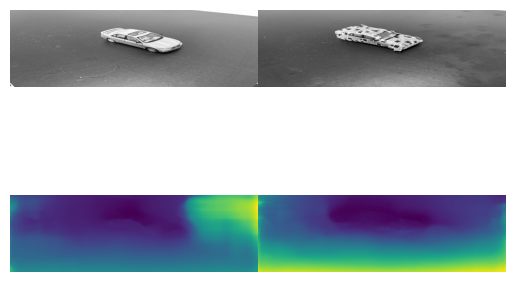

In [148]:
def print_car_pairs(idx1, idx2):
    print(car_tensors[idx1].shape, car_tensors[idx2].shape)
    input_image = input_resize(car_tensors[idx1])
    input_image0 = input_resize(car_tensors[idx2])
    print(input_image.shape, input_image0.shape)
    with torch.no_grad():
        outputs = depth_model(input_image.unsqueeze(dim=0))
        outputs0 = depth_model(input_image0.unsqueeze(dim=0))

    print(outputs.shape, outputs0.shape)

    png0 = cv2.cvtColor((input_image[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    outputs_png = outputs[0][0].detach().cpu().numpy()

    plt.figure()
    plt.subplot(2, 2, 1)
    plt.imshow(png0)
    plt.axis('off')
    plt.subplot(2, 2, 3)
    plt.imshow(outputs_png)
    plt.axis('off')

    png1 = cv2.cvtColor((input_image0[0].detach().cpu().numpy()*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    outputs0_png = outputs0[0][0].detach().cpu().numpy()

    plt.subplot(2, 2, 2)
    plt.imshow(png1)
    plt.axis('off')
    plt.subplot(2, 2, 4)
    plt.imshow(outputs0_png)
    plt.axis('off')
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


print_car_pairs(0, 3)
print_car_pairs(1, 4)
print_car_pairs(2, 5)

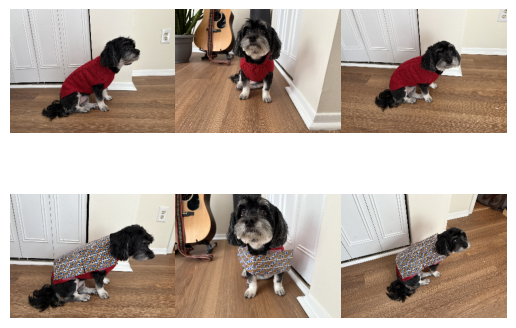

In [152]:
lily_angle = './test/IMG_4033.jpg'
lily_side = './test/IMG_4034.jpg'
lily_front = './test/IMG_4035.jpg'
lily_camou_side = './test/IMG_4037.jpg'
lily_camou_angle = './test/IMG_4038.jpg'
lily_camou_front = './test/IMG_4039.jpg'
image_paths = [lily_side, lily_front, lily_angle, lily_camou_side, lily_camou_front, lily_camou_angle]

lily_tensors = print_list(image_paths)

torch.Size([3, 4284, 5712]) torch.Size([3, 4284, 5712])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([1, 1, 320, 1024]) torch.Size([1, 1, 320, 1024])


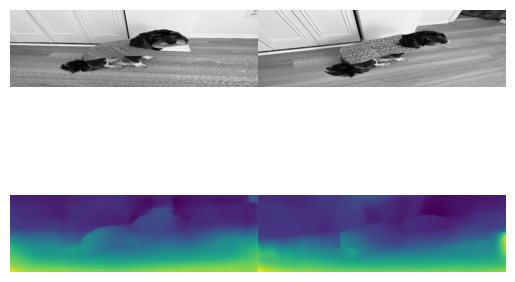

torch.Size([3, 4284, 5712]) torch.Size([3, 4284, 5712])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([1, 1, 320, 1024]) torch.Size([1, 1, 320, 1024])


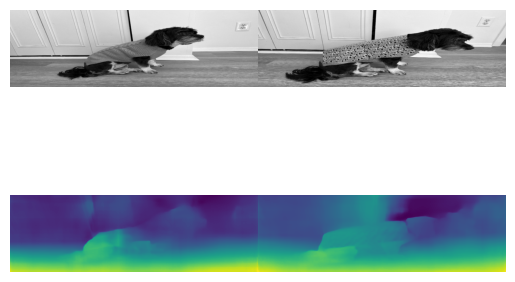

torch.Size([3, 4284, 5712]) torch.Size([3, 4284, 5712])
torch.Size([3, 320, 1024]) torch.Size([3, 320, 1024])
torch.Size([1, 1, 320, 1024]) torch.Size([1, 1, 320, 1024])


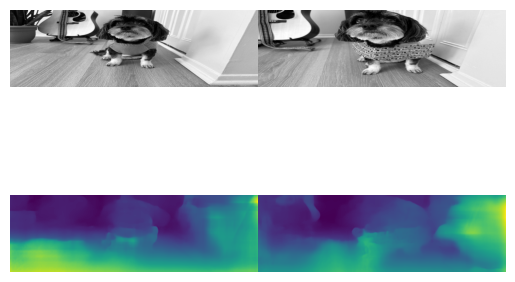

In [154]:
print_car_pairs(2, 5)
print_car_pairs(0, 3)
print_car_pairs(1, 4)